In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
df = pd.read_csv("blinkit_orders.csv")
df.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741


In [22]:
df.shape


(5000, 11)

In [9]:
df.isnull().sum()
df.drop_duplicates(inplace = True)

In [10]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['promised_delivery_time'] = pd.to_datetime(df['promised_delivery_time'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

In [11]:
df['delivery_time'] = (
    df['actual_delivery_time'] - df['order_date']
).dt.total_seconds()/60

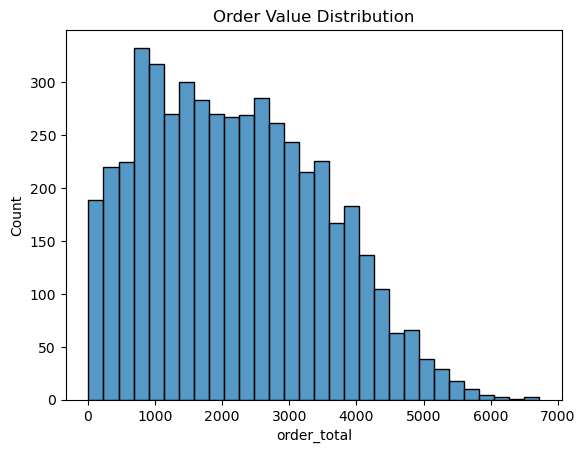

In [14]:

sns.histplot(df['order_total'], bins=30)

plt.title("Order Value Distribution")

plt.show()

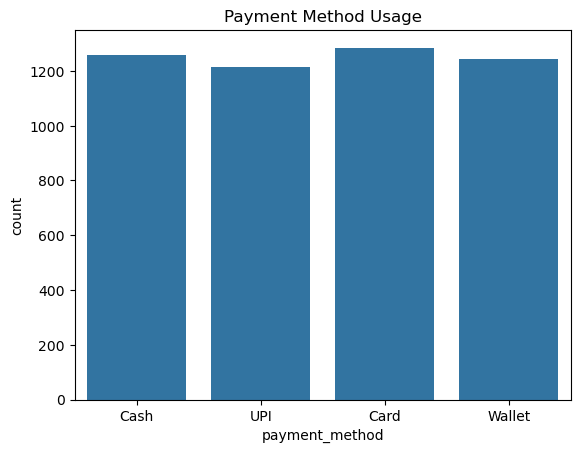

In [15]:
sns.countplot(x='payment_method', data=df)

plt.title("Payment Method Usage")

plt.show()

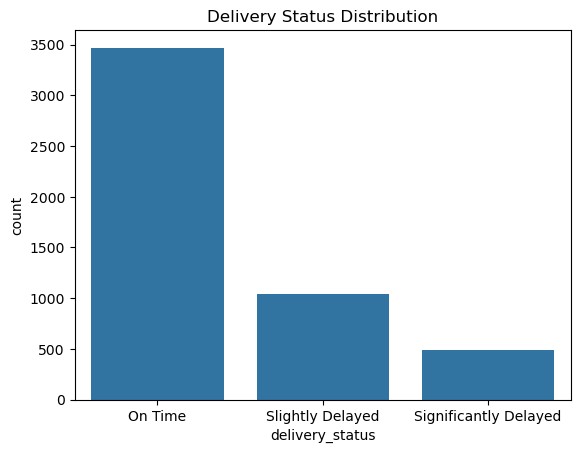

In [16]:
sns.countplot(x='delivery_status', data=df)

plt.title("Delivery Status Distribution")

plt.show()

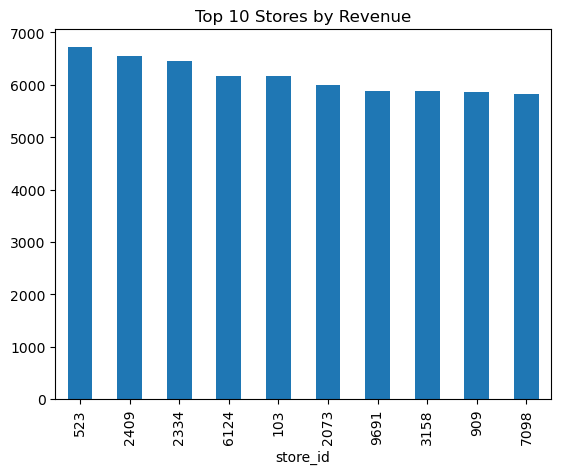

In [17]:
top_stores = df.groupby('store_id')['order_total'].sum().sort_values(ascending=False).head(10)

top_stores.plot(kind='bar')

plt.title("Top 10 Stores by Revenue")

plt.show()

In [18]:
X = df[['delivery_time']]
y = df['order_total']

In [23]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [28]:
predictions = model.predict(X_test)

In [30]:
print("R2 Score:", r2_score(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))

R2 Score: -0.000622697636670777
MSE: 1747793.8074322697


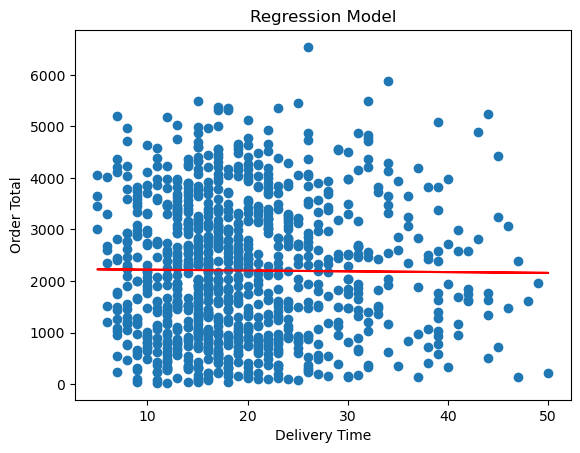

In [31]:
plt.scatter(X_test, y_test)

plt.plot(X_test, predictions, color='red')

plt.xlabel("Delivery Time")

plt.ylabel("Order Total")

plt.title("Regression Model")

plt.show()